# H3 - Performance a court terme des IPO (30 jours)

## Hypothese testee
La performance a 30 jours des IPO de la cohorte **2022-2024** est **plus stable et moins volatile** que celle de la cohorte **2019-2021**.

## Protocole d'evaluation
1. Comparaison des ecarts-types des rendements a 30 jours (`ret_30d`) entre cohortes.
2. Construction d'intervalles de confiance a 95% (bootstrap) pour:
   - la moyenne,
   - la mediane,
   - l'ecart-type des rendements a 30 jours.
3. Test de Mann-Whitney unilateral (H1: 2022-2024 < 2019-2021 en termes de rendement 30j).

## Donnees
- `data/dataset_complet_filled.xlsx`

> Aucune simulation n'est utilisee.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 120})

SEED = 42
COLORS = {"2019-2021": "#2C7BB6", "2022-2024": "#D7191C"}

print("Imports OK")

Imports OK


In [2]:
DATA_PATH = "data/dataset_complet_filled.xlsx"
df = pd.read_excel(DATA_PATH)

required = ["year", "ret_30d"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes: {missing}")

# Perimetre H3
df = df[df["year"].between(2019, 2024)].copy()
df["cohort"] = np.where(df["year"].between(2019, 2021), "2019-2021", "2022-2024")

# Optionnel: garder la logique taille d'emission >= 50 M$ si disponible
if "ipo_size_m" in df.columns:
    df = df[(df["ipo_size_m"].isna()) | (pd.to_numeric(df["ipo_size_m"], errors="coerce") >= 50)].copy()

df["ret_30d"] = pd.to_numeric(df["ret_30d"], errors="coerce")
work = df.dropna(subset=["ret_30d"]).copy()

r_19_21 = work.loc[work["cohort"] == "2019-2021", "ret_30d"].to_numpy()
r_22_24 = work.loc[work["cohort"] == "2022-2024", "ret_30d"].to_numpy()

print(f"Fichier: {DATA_PATH}")
print(f"Lignes apres filtres: {len(df)}")
print("\nEffectifs ret_30d non manquants:")
print(work["cohort"].value_counts())
print(f"\nN 2019-2021 = {len(r_19_21)}")
print(f"N 2022-2024 = {len(r_22_24)}")

Fichier: data/dataset_complet_filled.xlsx
Lignes apres filtres: 321

Effectifs ret_30d non manquants:
cohort
2019-2021    237
2022-2024     84
Name: count, dtype: int64

N 2019-2021 = 237
N 2022-2024 = 84


In [3]:
def summarize_returns(label: str) -> dict:
    x = work.loc[work["cohort"] == label, "ret_30d"].dropna().to_numpy()
    return {
        "Cohorte": label,
        "N": len(x),
        "Moyenne": np.mean(x) if len(x) else np.nan,
        "Mediane": np.median(x) if len(x) else np.nan,
        "Ecart-type": np.std(x, ddof=1) if len(x) > 1 else np.nan,
        "Q1": np.percentile(x, 25) if len(x) else np.nan,
        "Q3": np.percentile(x, 75) if len(x) else np.nan,
    }

desc = pd.DataFrame([
    summarize_returns("2019-2021"),
    summarize_returns("2022-2024")
])

display(desc.style.format({
    "Moyenne": "{:.4f}",
    "Mediane": "{:.4f}",
    "Ecart-type": "{:.4f}",
    "Q1": "{:.4f}",
    "Q3": "{:.4f}",
}))

,Cohorte,N,Moyenne,Mediane,Ecart-type,Q1,Q3
0,2019-2021,237,0.0425,0.0077,0.2882,-0.1145,0.1699
1,2022-2024,84,-0.0588,0.0203,0.2940,-0.1319,0.1231


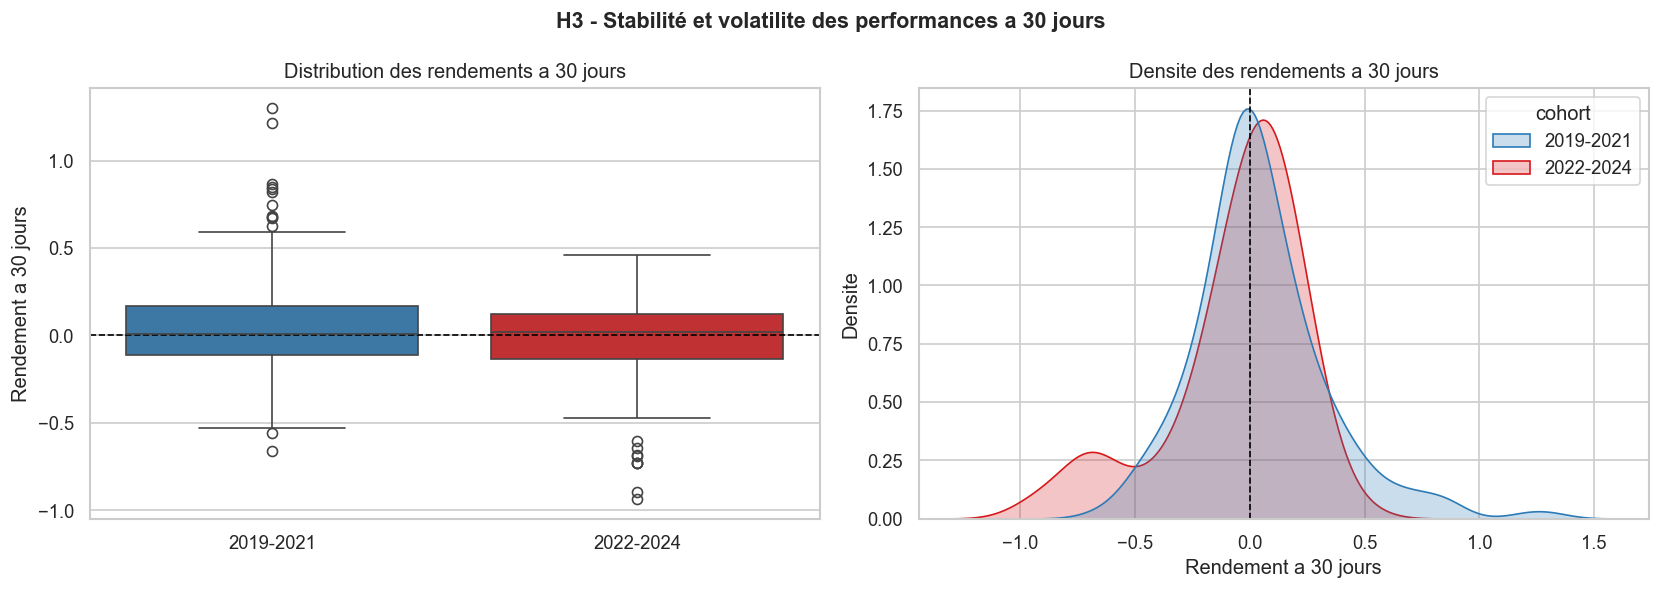

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=work,
    x="cohort",
    y="ret_30d",
    order=["2019-2021", "2022-2024"],
    palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
    ax=axes[0],
)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("")
axes[0].set_ylabel("Rendement a 30 jours")
axes[0].set_title("Distribution des rendements a 30 jours")

sns.kdeplot(
    data=work,
    x="ret_30d",
    hue="cohort",
    hue_order=["2019-2021", "2022-2024"],
    fill=True,
    common_norm=False,
    palette=[COLORS["2019-2021"], COLORS["2022-2024"]],
    alpha=0.25,
    ax=axes[1],
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Rendement a 30 jours")
axes[1].set_ylabel("Densite")
axes[1].set_title("Densite des rendements a 30 jours")

fig.suptitle("H3 - Stabilité et volatilite des performances a 30 jours", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
def bootstrap_ci_stat(x, stat_fn, n_boot=10_000, alpha=0.05, seed=SEED):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    gen = np.random.default_rng(seed)
    idx = gen.integers(0, len(x), size=(n_boot, len(x)))
    boot = stat_fn(x[idx], axis=1)
    est = stat_fn(x)
    lo = np.quantile(boot, alpha / 2)
    hi = np.quantile(boot, 1 - alpha / 2)
    return est, lo, hi

mean_19, mean_19_lo, mean_19_hi = bootstrap_ci_stat(r_19_21, np.mean, seed=SEED)
mean_22, mean_22_lo, mean_22_hi = bootstrap_ci_stat(r_22_24, np.mean, seed=SEED + 1)

med_19, med_19_lo, med_19_hi = bootstrap_ci_stat(r_19_21, np.median, seed=SEED + 2)
med_22, med_22_lo, med_22_hi = bootstrap_ci_stat(r_22_24, np.median, seed=SEED + 3)

std_19, std_19_lo, std_19_hi = bootstrap_ci_stat(r_19_21, lambda z, axis=None: np.std(z, axis=axis, ddof=1), seed=SEED + 4)
std_22, std_22_lo, std_22_hi = bootstrap_ci_stat(r_22_24, lambda z, axis=None: np.std(z, axis=axis, ddof=1), seed=SEED + 5)

ci_table = pd.DataFrame({
    "Cohorte": ["2019-2021", "2022-2024"],
    "Moyenne": [mean_19, mean_22],
    "IC95 Moyenne": [f"[{mean_19_lo:.4f} ; {mean_19_hi:.4f}]", f"[{mean_22_lo:.4f} ; {mean_22_hi:.4f}]"],
    "Mediane": [med_19, med_22],
    "IC95 Mediane": [f"[{med_19_lo:.4f} ; {med_19_hi:.4f}]", f"[{med_22_lo:.4f} ; {med_22_hi:.4f}]"],
    "Ecart-type": [std_19, std_22],
    "IC95 Ecart-type": [f"[{std_19_lo:.4f} ; {std_19_hi:.4f}]", f"[{std_22_lo:.4f} ; {std_22_hi:.4f}]"],
})

display(ci_table.style.format({
    "Moyenne": "{:.4f}",
    "Mediane": "{:.4f}",
    "Ecart-type": "{:.4f}",
}))

print("=== Volatilite comparee ===")
print(f"Ecart-type 2019-2021 : {std_19:.4f} (IC95 [{std_19_lo:.4f} ; {std_19_hi:.4f}])")
print(f"Ecart-type 2022-2024 : {std_22:.4f} (IC95 [{std_22_lo:.4f} ; {std_22_hi:.4f}])")

,Cohorte,Moyenne,IC95 Moyenne,Mediane,IC95 Mediane,Ecart-type,IC95 Ecart-type
0,2019-2021,0.0425,[0.0061 ; 0.0796],0.0077,[-0.0144 ; 0.0319],0.2882,[0.2489 ; 0.3265]
1,2022-2024,-0.0588,[-0.1221 ; 0.0024],0.0203,[-0.0438 ; 0.0739],0.2940,[0.2325 ; 0.3436]


=== Volatilite comparee ===
Ecart-type 2019-2021 : 0.2882 (IC95 [0.2489 ; 0.3265])
Ecart-type 2022-2024 : 0.2940 (IC95 [0.2325 ; 0.3436])


In [6]:
alpha = 0.05

# Mann-Whitney unilateral: H1 = rendements 2022-2024 plus faibles (moins exuberants) que 2019-2021
# -> alternative='less' sur la comparaison (2022-2024 vs 2019-2021)
if len(r_19_21) > 0 and len(r_22_24) > 0:
    u_stat, p_mw = stats.mannwhitneyu(r_22_24, r_19_21, alternative="less")
else:
    u_stat, p_mw = np.nan, np.nan

# Test de Levene (robuste) pour egalite des variances, en complement
if len(r_19_21) > 1 and len(r_22_24) > 1:
    lev_stat, p_lev = stats.levene(r_19_21, r_22_24, center="median")
else:
    lev_stat, p_lev = np.nan, np.nan

results = pd.DataFrame({
    "Test": [
        "Mann-Whitney U (H1: ret_30d 2022-2024 < 2019-2021)",
        "Levene (egalite des variances, complement)",
    ],
    "Statistique": [u_stat, lev_stat],
    "p-value": [p_mw, p_lev],
    "Significatif a 5%": [bool(np.isfinite(p_mw) and p_mw < alpha), bool(np.isfinite(p_lev) and p_lev < alpha)],
})

display(results.style.format({"Statistique": "{:.4f}", "p-value": "{:.4f}"}))

h3_vol_ok = bool(np.isfinite(std_19) and np.isfinite(std_22) and std_22 < std_19)
h3_mw_ok = bool(np.isfinite(p_mw) and p_mw < alpha)

print("\n=== Decision H3 ===")
print("Condition volatilite (ecart-type 2022-2024 < 2019-2021):", "OK" if h3_vol_ok else "NON")
print("Condition Mann-Whitney (p < 0,05):", "OK" if h3_mw_ok else "NON")
print("Conclusion H3:", "CONFIRMEE" if (h3_vol_ok and h3_mw_ok) else "PARTIELLE/NON CONFIRMEE")

,Test,Statistique,p-value,Significatif a 5%
0,Mann-Whitney U (H1: ret_30d 2022-2024 < 2019-2021),9157.0000,0.1379,False
1,"Levene (egalite des variances, complement)",0.0200,0.8877,False



=== Decision H3 ===
Condition volatilite (ecart-type 2022-2024 < 2019-2021): NON
Condition Mann-Whitney (p < 0,05): NON
Conclusion H3: PARTIELLE/NON CONFIRMEE


In [7]:
summary_final = pd.DataFrame({
    "Indicateur": [
        "Ecart-type ret_30d",
        "IC95 ecart-type",
        "Mediane ret_30d",
        "IC95 mediane",
        "Moyenne ret_30d",
        "IC95 moyenne",
        "p-value Mann-Whitney",
        "p-value Levene (complement)",
    ],
    "2019-2021": [
        f"{std_19:.4f}",
        f"[{std_19_lo:.4f} ; {std_19_hi:.4f}]",
        f"{med_19:.4f}",
        f"[{med_19_lo:.4f} ; {med_19_hi:.4f}]",
        f"{mean_19:.4f}",
        f"[{mean_19_lo:.4f} ; {mean_19_hi:.4f}]",
        "",
        "",
    ],
    "2022-2024": [
        f"{std_22:.4f}",
        f"[{std_22_lo:.4f} ; {std_22_hi:.4f}]",
        f"{med_22:.4f}",
        f"[{med_22_lo:.4f} ; {med_22_hi:.4f}]",
        f"{mean_22:.4f}",
        f"[{mean_22_lo:.4f} ; {mean_22_hi:.4f}]",
        "",
        "",
    ],
    "Valeur test": [
        "",
        "",
        "",
        "",
        "",
        "",
        f"{p_mw:.4f}" if np.isfinite(p_mw) else "NA",
        f"{p_lev:.4f}" if np.isfinite(p_lev) else "NA",
    ],
})

display(summary_final)

print("\nLecture:")
print("- H3 est fortement soutenue si l'ecart-type 2022-2024 est inferieur ET si Mann-Whitney est significatif.")
print("- Levene est un test complementaire sur l'egalite des variances.")

,Indicateur,2019-2021,2022-2024,Valeur test
0,Ecart-type ret_30d,0.2882,0.2940,
1,IC95 ecart-type,[0.2489 ; 0.3265],[0.2325 ; 0.3436],
2,Mediane ret_30d,0.0077,0.0203,
3,IC95 mediane,[-0.0144 ; 0.0319],[-0.0438 ; 0.0739],
4,Moyenne ret_30d,0.0425,-0.0588,
5,IC95 moyenne,[0.0061 ; 0.0796],[-0.1221 ; 0.0024],
6,p-value Mann-Whitney,,,0.1379
7,p-value Levene (complement),,,0.8877



Lecture:
- H3 est fortement soutenue si l'ecart-type 2022-2024 est inferieur ET si Mann-Whitney est significatif.
- Levene est un test complementaire sur l'egalite des variances.
